# SARSA vs Q-learning: on-policy and off-policy TD, side by side

Both algorithms have identical action selection (ε-greedy on the current \(\hat Q\)). The **only** algorithmic difference is what gets substituted for the value of the next state in the TD target:

* **SARSA** uses \($\hat Q(s_{t+1}, a_{t+1})$\) — the value at the action the agent will actually take next.
* **Q-learning** uses \($\max_{a'} \hat Q(s_{t+1}, a')$\) — the value of the greedy action, whether the agent will take it or not.

This notebook trains both on the cliff-walking gridworld of \citep{SuttonBarto2018}, with **identical RNG seeds** so their exploration intent is matched, and visualises how the single line of code that differs produces qualitatively different learned policies.

<small>*Drafted with the assistance of Claude (Anthropic).*</small>

In [1]:
import sys, os
from pathlib import Path
# Locate repo root portably (the dir containing utils/), so this
# notebook runs anywhere it is checked out.
_p = Path.cwd()
while _p != _p.parent and not (_p / 'utils' / 'toy_mdp.py').exists():
    _p = _p.parent
REPO = str(_p)
sys.path.insert(0, REPO)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Tuple, List, Optional

# We use sarsa() and q_learning() from utils.toy_mdp, but with a custom
# CliffWalkingEnv defined inline below so the notebook is self-contained.
from utils.toy_mdp import sarsa, q_learning, mc_control, epsilon_greedy

np.set_printoptions(precision=2, suppress=True)
plt.rcParams['figure.dpi'] = 100

## 1. The cliff-walking gridworld

A 4×12 grid. Agent starts at the bottom-left, goal is the bottom-right. The cells in between along the bottom row are **cliffs**: stepping into them returns the agent to the start and incurs a heavy −100 reward, but does not end the episode. Every other step costs −1. Reaching the goal gives 0 and terminates.

The structural feature: the **optimal deterministic** path runs along the very edge of the cliff (length 13, return −12). The **safe** path — detoured one row up — is longer (length 15, return −14) but tolerates exploratory missteps without falling.

In [2]:
class CliffWalkingEnv:
    """
    Sutton & Barto Example 6.6 cliff-walking gridworld.

    Grid: 4 rows x 12 cols
    Start: (3, 0); Goal: (3, 11)
    Cliff: (3, 1), (3, 2), ..., (3, 10)  -- bottom row between start and goal
    Actions: 0=up, 1=down, 2=left, 3=right

    Rewards: -1 per step, -100 if stepping into cliff (and teleport to start),
             0 at goal (terminal).
    """
    MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right

    def __init__(self, H: int = 4, W: int = 12, max_steps: int = 500,
                 gamma: float = 1.0):
        self.H, self.W = H, W
        self.n_states  = H * W
        self.n_actions = 4
        self.start = (H - 1, 0)
        self.goal  = (H - 1, W - 1)
        self.cliff = {(H - 1, c) for c in range(1, W - 1)}
        self.max_steps = max_steps
        self.gamma = gamma
        self.reset()

    def _flat(self, r, c): return r * self.W + c

    def reset(self) -> int:
        self.pos = self.start
        self.step_count = 0
        return self._flat(*self.pos)

    def step(self, action: int) -> Tuple[int, float, bool]:
        dr, dc = self.MOVES[action]
        r, c   = self.pos
        nr, nc = r + dr, c + dc
        # Clip to grid
        nr = max(0, min(self.H - 1, nr))
        nc = max(0, min(self.W - 1, nc))

        self.step_count += 1
        new_pos = (nr, nc)

        if new_pos in self.cliff:
            reward = -100.0
            self.pos = self.start  # teleport back to start
            done = self.step_count >= self.max_steps
        elif new_pos == self.goal:
            reward = 0.0
            self.pos = new_pos
            done = True
        else:
            reward = -1.0
            self.pos = new_pos
            done = self.step_count >= self.max_steps

        return self._flat(*self.pos), reward, done

env = CliffWalkingEnv()
print(f'States: {env.n_states}, Actions: {env.n_actions}')
print(f'Start: {env.start}, Goal: {env.goal}')
print(f'Cliff cells: {sorted(env.cliff)}')

States: 48, Actions: 4
Start: (3, 0), Goal: (3, 11)
Cliff cells: [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10)]


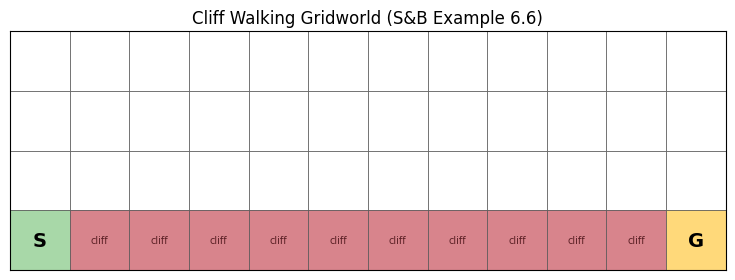

In [3]:
def draw_cliff(env, ax=None, title=''):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 2.8))
    for r in range(env.H):
        for c in range(env.W):
            cell = (r, c)
            if cell in env.cliff:
                color = '#d8848c'
            elif cell == env.start:
                color = '#a8d8a8'
            elif cell == env.goal:
                color = '#ffd97a'
            else:
                color = 'white'
            ax.add_patch(plt.Rectangle((c, env.H - 1 - r), 1, 1,
                                        facecolor=color, edgecolor='#555',
                                        linewidth=0.5))
    # Labels
    ax.text(env.start[1] + 0.5, env.H - 1 - env.start[0] + 0.5, 'S',
            ha='center', va='center', fontsize=14, weight='bold')
    ax.text(env.goal[1] + 0.5, env.H - 1 - env.goal[0] + 0.5, 'G',
            ha='center', va='center', fontsize=14, weight='bold')
    for r, c in env.cliff:
        ax.text(c + 0.5, env.H - 1 - r + 0.5, 'cliff',
                ha='center', va='center', fontsize=7, color='#5a1f24')
    ax.set_xlim(0, env.W)
    ax.set_ylim(0, env.H)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return ax

draw_cliff(env, title='Cliff Walking Gridworld (S&B Example 6.6)')
plt.tight_layout()
plt.show()

## 2. The algorithms

We use the implementations from `utils.toy_mdp`. The two update equations, side by side:

```python
# SARSA — on-policy
a2 = epsilon_greedy(Q[s2], epsilon)   # next action sampled NOW
target = r + gamma * Q[s2, a2]        # uses the action that will be taken
Q[s, a] += alpha * (target - Q[s, a])

# Q-learning — off-policy
target = r + gamma * Q[s2].max()      # uses the greedy max, regardless of policy
Q[s, a] += alpha * (target - Q[s, a])
```

Both call `epsilon_greedy(Q[s], epsilon)` to select the action they execute. Only the **target** differs.

## 3. Training with matched RNG seeds

Both algorithms are reseeded to the **same initial RNG state** before training. This gives them the same starting position in the global numpy stream, so their first few actions agree.

This protocol does *not* lock exploration step-by-step across all episodes. SARSA makes \($T{+}1$\) ε-greedy calls per episode of length \($T$\) (one initialisation plus one per step), while Q-learning makes \($T$\). After the first episode the two algorithms' positions in the shared stream have drifted apart, so they no longer agree on which steps are exploration steps. Empirically, even within episode 0 the algorithms diverge after a handful of steps once Q-tables disagree on \(\arg\max\) at a state both happen to visit.

What matched seeds *do* buy: reproducibility, fair initial conditions, no algorithm getting a luckier random stream baked in. What they do *not* buy: lockstep exploration intent throughout training. A tighter comparison via **common random numbers** is added in §9 below.

In [4]:
N_EPISODES = 500
EPSILON    = 0.1
ALPHA      = 0.5
GAMMA      = 1.0
SEED       = 0

np.random.seed(SEED)
out_sarsa = sarsa(env, n_episodes=N_EPISODES, gamma=GAMMA,
                   epsilon=EPSILON, alpha=ALPHA)

env = CliffWalkingEnv()  # fresh env
np.random.seed(SEED)
out_q = q_learning(env, n_episodes=N_EPISODES, gamma=GAMMA,
                    epsilon=EPSILON, alpha=ALPHA)

# Optional sanity check: every-visit MC control
env = CliffWalkingEnv()
np.random.seed(SEED)
out_mc = mc_control(env, n_episodes=N_EPISODES, gamma=GAMMA,
                     epsilon=EPSILON, alpha=ALPHA)

print(f'SARSA       final 50-ep return mean: {np.mean(out_sarsa["returns"][-50:]):8.2f}')
print(f'Q-learning  final 50-ep return mean: {np.mean(out_q    ["returns"][-50:]):8.2f}')
print(f'MC control  final 50-ep return mean: {np.mean(out_mc   ["returns"][-50:]):8.2f}')

SARSA       final 50-ep return mean:   -18.42
Q-learning  final 50-ep return mean:   -46.00
MC control  final 50-ep return mean:   -68.54


## 4. Learning curves

Episode returns during training. SARSA tracks the value of the policy it **actually executes** (ε-greedy, including the cost of occasional cliff falls), so it learns a path that holds up under ε-greedy execution. Q-learning tracks the value of the **greedy** policy regardless of behaviour, so it walks the cliff edge — fine for the greedy policy at deployment, but during ε-greedy training the 10% exploration rate means it falls off the cliff regularly.

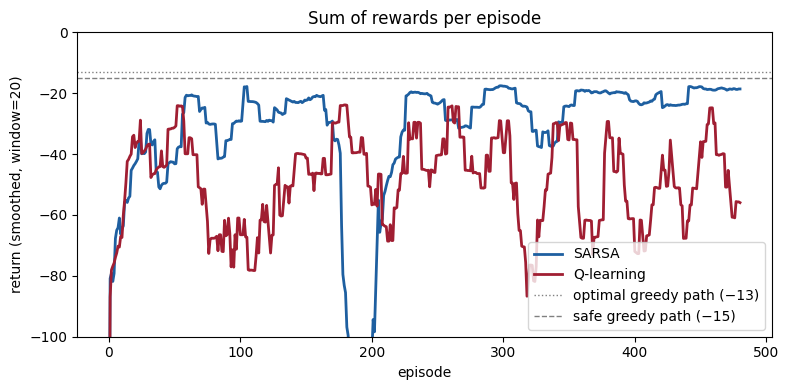

In [5]:
def smooth(x, window=20):
    x = np.asarray(x, dtype=float)
    pad = window // 2
    cs  = np.cumsum(np.concatenate([[0.0], x]))
    out = (cs[window:] - cs[:-window]) / window
    return out

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(smooth(out_sarsa['returns']), color='#1e5fa0', label='SARSA',  lw=2)
ax.plot(smooth(out_q['returns']),     color='#a01e32', label='Q-learning', lw=2)
ax.axhline(-13, color='gray', ls=':',  lw=1, label='optimal greedy path (−13)')
ax.axhline(-15, color='gray', ls='--', lw=1, label='safe greedy path (−15)')
ax.set_xlabel('episode')
ax.set_ylabel('return (smoothed, window=20)')
ax.set_title('Sum of rewards per episode')
ax.legend(loc='lower right')
ax.set_ylim(-100, 0)
plt.tight_layout()
plt.show()

## 5. Learned greedy policies

Visualise the greedy action at each non-terminal state, derived from the learned \(\hat Q\). The structural prediction:

* Q-learning learns \($Q^{\star}$\), so its greedy policy follows the **optimal deterministic** path — along the cliff edge.
* SARSA learns \($Q^{\pi_{\epsilon}}$\) for the ε-greedy policy, which **knows about its own clumsiness** — so SARSA's greedy policy detours one row up, paying a small length cost for robustness to exploration.

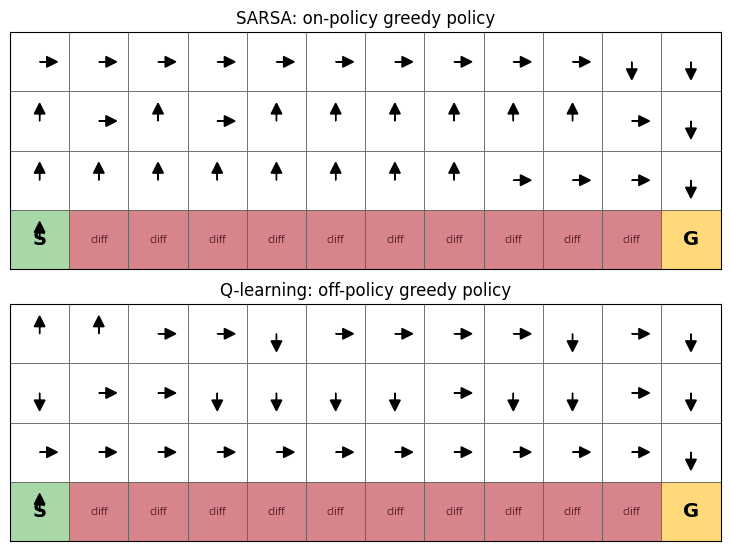

In [6]:
ARROWS = {0: (0, 0.3), 1: (0, -0.3), 2: (-0.3, 0), 3: (0.3, 0)}

def plot_policy(env, Q, ax, title=''):
    draw_cliff(env, ax=ax, title=title)
    for r in range(env.H):
        for c in range(env.W):
            cell = (r, c)
            if cell == env.goal or cell in env.cliff:
                continue
            s = env._flat(r, c)
            a = int(np.argmax(Q[s]))
            dx, dy = ARROWS[a]
            ax.arrow(c + 0.5, env.H - 1 - r + 0.5, dx, dy,
                     head_width=0.18, head_length=0.18, fc='black', ec='black',
                     length_includes_head=True)

fig, axes = plt.subplots(2, 1, figsize=(7.5, 5.6))
plot_policy(env, out_sarsa['Q'], axes[0], title='SARSA: on-policy greedy policy')
plot_policy(env, out_q['Q'],     axes[1], title='Q-learning: off-policy greedy policy')
plt.tight_layout()
plt.show()

## 6. Deterministic execution: what each greedy policy actually achieves

The on-policy/off-policy story has a payoff structure: SARSA optimises **training-time** performance, Q-learning optimises **deployment-time** performance. Roll out each learned greedy policy with \(\epsilon = 0\) to check.

In [7]:
def greedy_rollout(env, Q, max_steps=200):
    env = CliffWalkingEnv(max_steps=max_steps)
    s = env.reset()
    trajectory = [env.pos]
    total_r = 0.0
    done = False
    while not done:
        a = int(np.argmax(Q[s]))
        s, r, done = env.step(a)
        total_r += r
        trajectory.append(env.pos)
    return total_r, trajectory

env = CliffWalkingEnv()
r_sarsa, traj_sarsa = greedy_rollout(env, out_sarsa['Q'])
r_q,     traj_q     = greedy_rollout(env, out_q['Q'])

print(f'SARSA      greedy rollout: return = {r_sarsa:6.1f}, length = {len(traj_sarsa)-1:3d}')
print(f'Q-learning greedy rollout: return = {r_q:6.1f}, length = {len(traj_q    )-1:3d}')

SARSA      greedy rollout: return =  -16.0, length =  17
Q-learning greedy rollout: return =  -12.0, length =  13


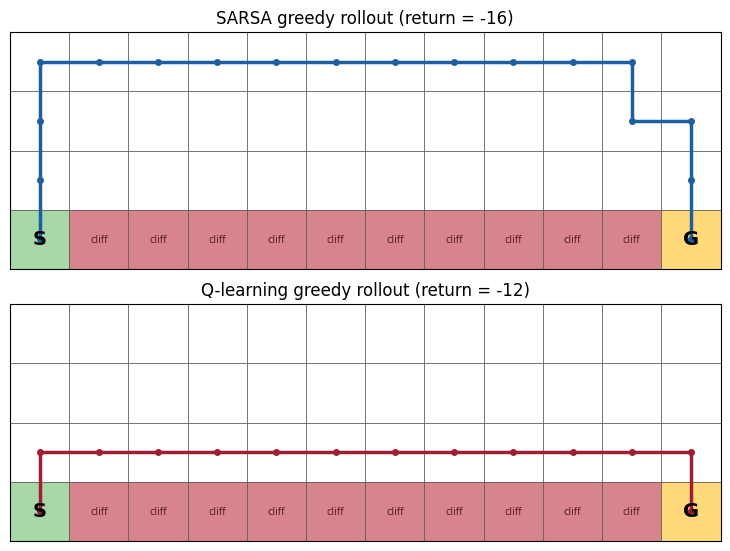

In [8]:
def plot_trajectory(env, traj, ax, title='', color='#1e5fa0'):
    draw_cliff(env, ax=ax, title=title)
    xs = [c + 0.5 for r, c in traj]
    ys = [env.H - 1 - r + 0.5 for r, c in traj]
    ax.plot(xs, ys, '-o', color=color, lw=2.5, markersize=4)

fig, axes = plt.subplots(2, 1, figsize=(7.5, 5.6))
plot_trajectory(env, traj_sarsa, axes[0],
                 title=f'SARSA greedy rollout (return = {r_sarsa:.0f})',
                 color='#1e5fa0')
plot_trajectory(env, traj_q, axes[1],
                 title=f'Q-learning greedy rollout (return = {r_q:.0f})',
                 color='#a01e32')
plt.tight_layout()
plt.show()

## 7. Averaging over seeds: the systematic difference

A single matched-seed run shows the mechanism but is noisy. Averaging the training curves over many seeds reveals the **systematic** behavioural difference: SARSA's training-time return is consistently higher (less catastrophic cliff falls), Q-learning's is consistently lower (it explores along the edge and falls regularly), but at the level of greedy deployment both can converge to good policies — just different ones.

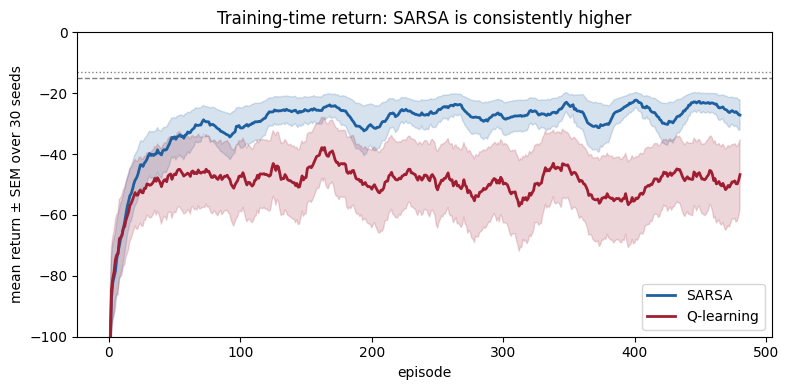

In [9]:
N_SEEDS = 30

returns_sarsa = np.zeros((N_SEEDS, N_EPISODES))
returns_q     = np.zeros((N_SEEDS, N_EPISODES))

for k in range(N_SEEDS):
    env = CliffWalkingEnv()
    np.random.seed(k)
    out_s = sarsa(env, n_episodes=N_EPISODES, gamma=GAMMA,
                   epsilon=EPSILON, alpha=ALPHA)
    returns_sarsa[k] = out_s['returns']

    env = CliffWalkingEnv()
    np.random.seed(k)
    out_q = q_learning(env, n_episodes=N_EPISODES, gamma=GAMMA,
                        epsilon=EPSILON, alpha=ALPHA)
    returns_q[k] = out_q['returns']

mean_sarsa = smooth(returns_sarsa.mean(axis=0))
mean_q     = smooth(returns_q.mean(axis=0))
sem_sarsa  = smooth(returns_sarsa.std(axis=0) / np.sqrt(N_SEEDS))
sem_q      = smooth(returns_q.std(axis=0)     / np.sqrt(N_SEEDS))

fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(len(mean_sarsa))
ax.plot(xs, mean_sarsa, color='#1e5fa0', lw=2, label='SARSA')
ax.fill_between(xs, mean_sarsa - sem_sarsa, mean_sarsa + sem_sarsa,
                 color='#1e5fa0', alpha=0.18)
ax.plot(xs, mean_q, color='#a01e32', lw=2, label='Q-learning')
ax.fill_between(xs, mean_q - sem_q, mean_q + sem_q,
                 color='#a01e32', alpha=0.18)
ax.axhline(-13, color='gray', ls=':',  lw=1)
ax.axhline(-15, color='gray', ls='--', lw=1)
ax.set_xlabel('episode')
ax.set_ylabel(f'mean return ± SEM over {N_SEEDS} seeds')
ax.set_title('Training-time return: SARSA is consistently higher')
ax.legend(loc='lower right')
ax.set_ylim(-100, 0)
plt.tight_layout()
plt.show()

## 8. Takeaways

1. **The algorithmic difference is one expression.** SARSA's target uses \($\hat Q(s_{t+1}$, $a_{t+1}$)\); Q-learning's uses \($\max_{a'}$ $\hat Q(s_{t+1}, a')$\). Everything downstream — the on-policy/off-policy split, the cliff-walking behavioural divergence, the maximisation-bias problem in Q-learning, the deadly-triad concerns under function approximation — follows from that one line.

2. **They learn different value functions on purpose.** SARSA estimates \($Q^{\pi_{\epsilon}}$\), the value of the ε-greedy policy actually being executed (which knows about the cost of exploring near a cliff). Q-learning estimates \($Q^{\star}$\), the value of the optimal greedy policy (which ignores exploration noise). Each is correct under its own definition.

3. **Training-time return ≠ deployment-time return.** Q-learning's greedy policy has *higher* deployment-time return (−13 along the edge vs −15 for the safe path), but its training-time return is *lower* because ε-greedy exploration along the edge is catastrophic. SARSA inverts this: better training-time, slightly suboptimal at deployment.

4. **When the two algorithms agree.** Set \($\epsilon = 0$\) (or anneal to 0 via GLIE), and the two methods coincide — because when behaviour is fully greedy, target equals behaviour automatically, and the on-policy / off-policy distinction collapses.

5. **The structural lesson.** The on-policy/off-policy axis is **orthogonal** to the MC vs TD axis. SARSA and MC control are both on-policy; Q-learning is off-policy by Mechanism B (the \($\max$\) makes the target operator \($\mathcal{T}^{\star}_Q$\) policy-free, so no importance sampling is needed). Off-policy methods with policy-dependent targets (off-policy MC, off-policy TD for \($Q^{\pi}$\)) need Mechanism A — importance sampling — instead.

## 9. Common random numbers: tightening the comparison

The matched-seed run in §3 locks the *initial state* of the RNG, not the *decisions* the RNG makes downstream. To attribute behavioural differences to the algorithms themselves rather than to drift in the random stream, we need a tighter protocol.

Decompose ε-greedy's randomness at each step \($\tau$\) into two independent draws: a Bernoulli(ε) coin \($c_\tau$\) deciding explore-vs-exploit, and (only if exploring) a uniform action \($u_\tau \in \{0,\dots,|A|{-}1\}$\). If both algorithms read the *same* \(($c_\tau$, $u_\tau$)\) at step \($\tau$\):

* they decide to explore on the same steps,
* when exploring, they take the same action,
* when exploiting, each picks \(\arg\max_a \hat Q[s_\tau, a]\) — which can differ between the two algorithms once their Q-tables (or their states, after prior divergence) disagree, **and only then**.

This is the simulation-literature technique of **common random numbers** (CRN): when comparing two stochastic systems, lock the noise inputs and let only the systems' internal logic differ.

The implementation is an `ExplorationTape`: a store of \(($c_\tau$, $u_\tau$)\) pairs keyed by the timestep \($\tau$\) of the action that is *executed* at that step. The key subtlety is the call-timing asymmetry. Q-learning's ε-greedy call at step \(t\) selects the action executed at step \($t$\). SARSA's call at the *end* of step \(t\) selects the action executed at step \(t+1\) (its TD target needs \($a_{t+1}$\)), plus one priming call for \($a_0$\). Indexing the tape by *executed timestep* rather than by call-order means both algorithms read the same slot for the action at step \($\tau$\), regardless of when in their control flow the draw happens. Each slot derives its randomness from \(\text{hash}(\text{seed}, $\tau$)\), so a slot's value is independent of the order in which slots are first accessed.

Two coupling modes, controlled by `share_explore_action`:

* **`True` (full CRN).** Both algorithms read the same coin *and*, on explore steps, the same action \($u_\tau$\). The only thing that can differ is the exploit action — \($\arg\max_a \hat Q$\) — and only once the Q-tables disagree.
* **`False` (shared schedule only).** The coin \($c_\tau$\) is still shared, so both algorithms explore on the same steps, but each draws its own explore action. This fixes the exploration *schedule* while marginalising over exploration *content*.

There is no "share action but not coin" mode: if the coins differ, only one algorithm is exploring that step, so there is no shared action to speak of. Fully decoupled exploration is just the legacy path — two separate runs with independent RNGs.

In [10]:
from utils.toy_mdp import make_tape_factory

MASTER_SEED = 0

# An ExplorationTape stores (coin, explore-action) keyed by the timestep of
# the EXECUTED action, not by call-order. SARSA's epsilon-greedy call at the
# end of step t selects the action for step t+1 (plus a priming call for
# step 0); Q-learning's call at step t selects the action for step t.
# Timestep-indexing means both algorithms read the same slot for the action
# executed at step tau, despite that call-timing asymmetry.
tape_factory = make_tape_factory(MASTER_SEED, n_actions=4)

env = CliffWalkingEnv()
out_sarsa_crn = sarsa(env, n_episodes=N_EPISODES, gamma=GAMMA,
                      epsilon=EPSILON, alpha=ALPHA,
                      tape_factory=tape_factory,
                      share_explore_action=True,
                      record_trajectories=True)

env = CliffWalkingEnv()
out_q_crn = q_learning(env, n_episodes=N_EPISODES, gamma=GAMMA,
                       epsilon=EPSILON, alpha=ALPHA,
                       tape_factory=tape_factory,
                       share_explore_action=True,
                       record_trajectories=True)

print(f'SARSA      (CRN) final 50-ep return mean: '
      f'{np.mean(out_sarsa_crn["returns"][-50:]):8.2f}')
print(f'Q-learning (CRN) final 50-ep return mean: '
      f'{np.mean(out_q_crn    ["returns"][-50:]):8.2f}')

SARSA      (CRN) final 50-ep return mean:   -20.88
Q-learning (CRN) final 50-ep return mean:   -54.16


### Diagnostic: first divergence step per episode

Within each episode, the first step \($k$\) at which SARSA and Q-learning executed different actions. `None` means the executed actions agreed for the length of the shorter trajectory.

Under `share_explore_action=True` there is one clean structural invariant, and it is worth stating carefully because it is what makes the diagnostic meaningful.

**The first divergence is always an exploit step.** Consider the first step \($k$\) at which the two algorithms differ. By definition every step before \($k$\) agreed, so the two trajectories *coincide* up to step \($k$\) — in particular both algorithms are in the **same state** \($s_k$\) and both read the **same tape slot** \(($c_k, u_k$)\). If \($c_k < \epsilon$\) (an explore step), full CRN makes both execute the shared action \($u_k$\), so they would *not* differ at \(k\) — contradiction. Hence \($c_k \ge \epsilon$\): step \($k$\) is an exploit step, and the two algorithms diverge precisely because \($\arg\max_a \hat Q^{\text{SARSA}}[s_k, a] \ne \arg\max_a \hat Q^{\text{Q}}[s_k, a]$\).

So every divergence traces to a single identifiable event: an \($\arg\max$\) disagreement at a shared state. Note the argument only constrains the *first* divergence step. After step \(k\) the two agents are in different states; they still read the same tape slot by index, but "step \($\tau$\)" no longer denotes a shared situation, so later explore steps can and do produce different actions.

(Contrast `share_explore_action=False`: the coin is shared but the explore action is not, so an explore step *can* be the first divergence — the §9.1 comparison below shows this directly.)

In [11]:
def first_divergence(traj_a, traj_b):
    """First step index where executed actions differ; None if they agree
    for the length of the shorter trajectory."""
    for k, ((_, a_a), (_, a_b)) in enumerate(zip(traj_a, traj_b)):
        if a_a != a_b:
            return k
    return None

t_sarsa = out_sarsa_crn['trajectories']
t_q     = out_q_crn['trajectories']

divs = [first_divergence(t_sarsa[ep], t_q[ep]) for ep in range(N_EPISODES)]
diverged_mask = np.array([d is not None for d in divs])
div_steps     = np.array([d if d is not None else -1 for d in divs])

print(f'Episodes with divergence:    {diverged_mask.sum():3d} / {N_EPISODES}')
print(f'Episodes without divergence: {(~diverged_mask).sum():3d} / {N_EPISODES}')
if diverged_mask.any():
    print(f'Mean   first-divergence step (divergent only): '
          f'{div_steps[diverged_mask].mean():.2f}')
    print(f'Median first-divergence step (divergent only): '
          f'{np.median(div_steps[diverged_mask]):.0f}')

Episodes with divergence:    500 / 500
Episodes without divergence:   0 / 500
Mean   first-divergence step (divergent only): 1.32
Median first-divergence step (divergent only): 1


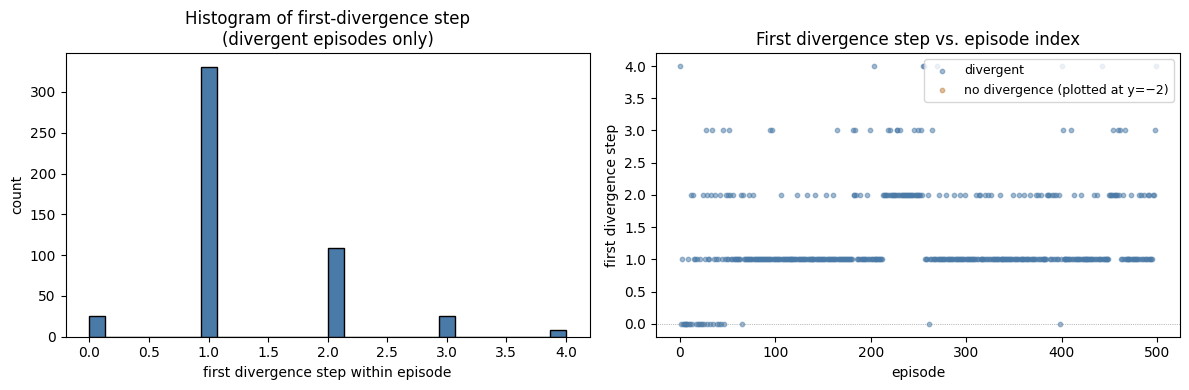

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
if diverged_mask.any():
    ax.hist(div_steps[diverged_mask], bins=30, edgecolor='black',
            color='#4a7aa7')
ax.set_xlabel('first divergence step within episode')
ax.set_ylabel('count')
ax.set_title('Histogram of first-divergence step\n(divergent episodes only)')

ax = axes[1]
ep_axis = np.arange(N_EPISODES)
ax.scatter(ep_axis[diverged_mask], div_steps[diverged_mask],
           s=10, alpha=0.5, color='#4a7aa7', label='divergent')
ax.scatter(ep_axis[~diverged_mask],
           np.full((~diverged_mask).sum(), -2),
           s=10, alpha=0.5, color='#c08040',
           label='no divergence (plotted at y=−2)')
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel('episode')
ax.set_ylabel('first divergence step')
ax.set_title('First divergence step vs. episode index')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 9.1 Coupling modes: sharing the explore action, or only the schedule

The run above used `share_explore_action=True` — full common random numbers. The coin \(c_\tau\) and the explore action \(u_\tau\) are both shared. The alternative, `share_explore_action=False`, shares only the coin: both algorithms still explore on exactly the same steps, but each draws its own random action when it does.

The two modes answer different questions. Full CRN asks: *given literally identical exploratory behaviour, how do the update rules diverge?* Schedule-only asks: *given the same explore/exploit rhythm but independent exploratory actions, how do they diverge?* — marginalising over exploration content.

The diagnostic consequence is sharp. Under full CRN the first divergence is always an exploit step (the invariant argued above). Under schedule-only that invariant breaks: before the first divergence both algorithms are in the same state and read the same coin, but on an explore step they now draw *independent* actions, so an explore step can itself be the first divergence. The cell below counts exactly this.

In [13]:
def run_pair(share_action, seed=MASTER_SEED):
    """Train SARSA and Q-learning against one shared tape factory."""
    tf = make_tape_factory(seed, n_actions=4)
    s = sarsa(CliffWalkingEnv(), n_episodes=N_EPISODES, gamma=GAMMA,
              epsilon=EPSILON, alpha=ALPHA, tape_factory=tf,
              share_explore_action=share_action, record_trajectories=True)
    tf = make_tape_factory(seed, n_actions=4)
    q = q_learning(CliffWalkingEnv(), n_episodes=N_EPISODES, gamma=GAMMA,
                   epsilon=EPSILON, alpha=ALPHA, tape_factory=tf,
                   share_explore_action=share_action, record_trajectories=True)
    return s, q

def divergence_origin_stats(s_out, q_out, seed=MASTER_SEED):
    """For each divergent episode, classify the first-divergence step as
    explore (coin < EPSILON) or exploit, using the shared tape's coin."""
    explore_origin = exploit_origin = 0
    for ep in range(N_EPISODES):
        d = first_divergence(s_out['trajectories'][ep],
                             q_out['trajectories'][ep])
        if d is None:
            continue
        coin, _ = make_tape_factory(seed, n_actions=4)(ep).get(d)
        if coin < EPSILON:
            explore_origin += 1
        else:
            exploit_origin += 1
    return explore_origin, exploit_origin

s_share,   q_share   = run_pair(share_action=True)
s_noshare, q_noshare = run_pair(share_action=False)

ex_T, ox_T = divergence_origin_stats(s_share,   q_share)
ex_F, ox_F = divergence_origin_stats(s_noshare, q_noshare)

print('first-divergence-step origin, by coupling mode:')
print(f'  share_explore_action=True : '
      f'{ex_T:3d} explore-origin, {ox_T:3d} exploit-origin')
print(f'  share_explore_action=False: '
      f'{ex_F:3d} explore-origin, {ox_F:3d} exploit-origin')
print()
print('Under full CRN the explore-origin count is 0 by the invariant; under')
print('schedule-only sharing it is positive — explore steps with independent')
print('actions become a second, separable source of trajectory divergence.')

first-divergence-step origin, by coupling mode:
  share_explore_action=True :   0 explore-origin, 500 exploit-origin
  share_explore_action=False:  79 explore-origin, 421 exploit-origin

Under full CRN the explore-origin count is 0 by the invariant; under
schedule-only sharing it is positive — explore steps with independent
actions become a second, separable source of trajectory divergence.


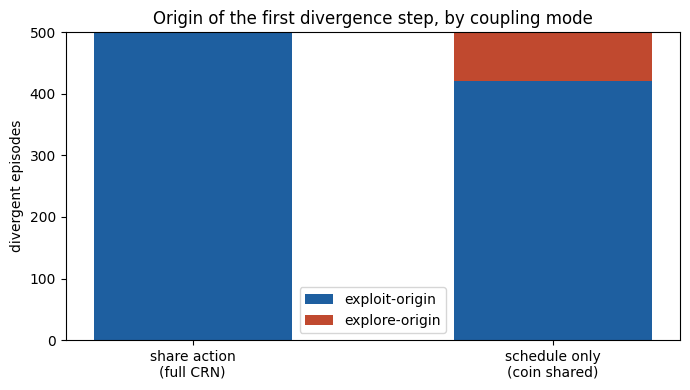

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
modes  = ['share action\n(full CRN)', 'schedule only\n(coin shared)']
explore = [ex_T, ex_F]
exploit = [ox_T, ox_F]
x = np.arange(2)
ax.bar(x, exploit, 0.55, label='exploit-origin', color='#1e5fa0')
ax.bar(x, explore, 0.55, bottom=exploit, label='explore-origin',
       color='#c0492f')
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.set_ylabel('divergent episodes')
ax.set_title('Origin of the first divergence step, by coupling mode')
ax.legend()
plt.tight_layout()
plt.show()

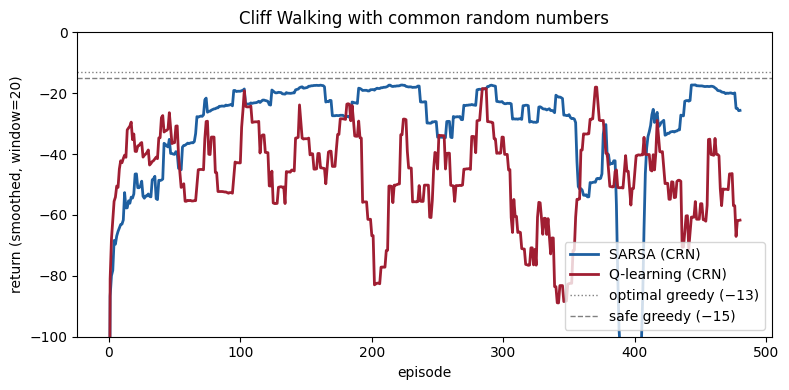

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(smooth(out_sarsa_crn['returns']), color='#1e5fa0', lw=2,
        label='SARSA (CRN)')
ax.plot(smooth(out_q_crn['returns']),     color='#a01e32', lw=2,
        label='Q-learning (CRN)')
ax.axhline(-13, color='gray', ls=':',  lw=1, label='optimal greedy (−13)')
ax.axhline(-15, color='gray', ls='--', lw=1, label='safe greedy (−15)')
ax.set_xlabel('episode')
ax.set_ylabel('return (smoothed, window=20)')
ax.set_title('Cliff Walking with common random numbers')
ax.legend(loc='lower right')
ax.set_ylim(-100, 0)
plt.tight_layout()
plt.show()

## 10. What CRN buys

Under common random numbers the two algorithms decide to explore on *exactly* the same set of global steps within each episode. Whether they also take the same exploratory *action* is the `share_explore_action` knob of §9.1: under full CRN they do, and the only remaining difference — which exploit action is taken when the algorithms disagree on \($\arg\max_a \hat Q$\) at the current state — is the algorithmic substance. Any state-space divergence past the first such disagreement cascades from that single attributable event.

The variance of the *difference* in performance drops to whatever the algorithms themselves generate, which is what you want for clean attribution: confounding from RNG drift is removed.

Two natural follow-ups this enables cleanly:

* **Expected SARSA** on the same env with the same factory. Expected SARSA's target \($r + \gamma \sum_{a'} \pi(a'|s') \hat Q(s', a')$\) coincides with SARSA's in expectation (\($\pi = \mu = \epsilon$\)-greedy) but with lower variance; under CRN the two should track each other tightly with Expected SARSA's curve visibly smoother.

* **GLIE annealing** \($\epsilon \to 0$\). With CRN locked, the convergence of SARSA's and Q-learning's greedy policies as exploration vanishes is a single per-episode trace rather than a noisy difference.

### 10.1 The paired difference $\Delta = R_S - R_Q$

The cleanest read on what the pairing does is to form the gap directly. For each master seed $k$ I build one shared exploration tape and train both algorithms against it (`share_explore_action=True`), so within a seed they face identical exploration until their greedy policies first disagree. The per-seed online-return gap $\Delta = R_S - R_Q$ is the estimand the pairing is meant to tighten; averaged over seeds it is SARSA's safety margin during learning.

On the cliff the two readings of "what CRN buys" come apart. The pairing removes the differing-exploration confound *by construction* — a fair comparison at matched exploration — but because the policies diverge early and stay diverged, the variance reduction is modest per episode and washes almost entirely out of the run-total gap. That is expected and fine: the reason to pair here is clean attribution, not variance, and with enough seeds the gap is what it is regardless.

In [16]:
# --- Paired difference Delta = R_S - R_Q across master seeds (full CRN) ---
# One shared exploration tape per seed; SARSA and Q-learning trained against it.
N_SEEDS_CRN = 100   # raise toward ~200 to tighten the run-total rho estimate

RS = np.zeros((N_SEEDS_CRN, N_EPISODES))
RQ = np.zeros((N_SEEDS_CRN, N_EPISODES))
for k in range(N_SEEDS_CRN):
    tf = make_tape_factory(k, n_actions=4)
    RS[k] = sarsa(CliffWalkingEnv(), n_episodes=N_EPISODES, gamma=GAMMA,
                  epsilon=EPSILON, alpha=ALPHA,
                  tape_factory=tf, share_explore_action=True)["returns"]
    tf = make_tape_factory(k, n_actions=4)
    RQ[k] = q_learning(CliffWalkingEnv(), n_episodes=N_EPISODES, gamma=GAMMA,
                       epsilon=EPSILON, alpha=ALPHA,
                       tape_factory=tf, share_explore_action=True)["returns"]

Delta = RS - RQ
print(f"ran {N_SEEDS_CRN} CRN-paired seeds; mean online Delta = {Delta.mean():+.2f}")

ran 100 CRN-paired seeds; mean online Delta = +18.71


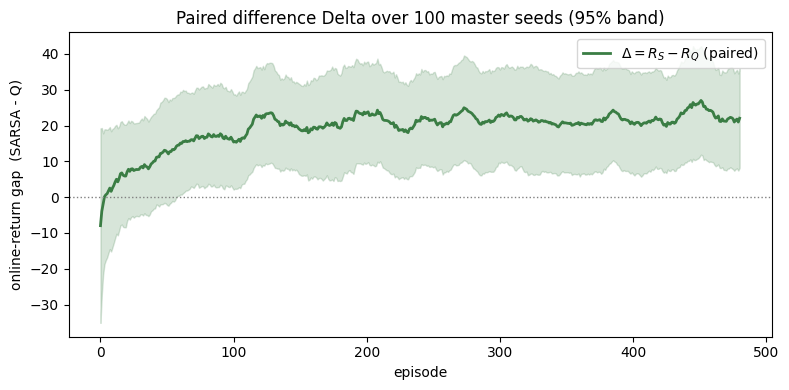

run-total   : rho = +0.059   variance-reduction factor = 1.06x
per-episode : rho = +0.239   variance-reduction factor = 1.24x

CRN removes the differing-exploration confound by construction (fair comparison);
the variance reduction is modest per-episode and washes out of the run total,
because the cliff makes the policies diverge early and stay diverged.


In [17]:
# --- Delta band, and how much variance the pairing actually bought ---
dmean = smooth(Delta.mean(0))
dsem  = smooth(Delta.std(0) / np.sqrt(N_SEEDS_CRN))
xs = np.arange(len(dmean))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, dmean, color="#3a7d44", lw=2, label=r"$\Delta = R_S - R_Q$ (paired)")
ax.fill_between(xs, dmean - 1.96 * dsem, dmean + 1.96 * dsem,
                color="#3a7d44", alpha=0.2)
ax.axhline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("episode")
ax.set_ylabel("online-return gap  (SARSA - Q)")
ax.set_title(f"Paired difference Delta over {N_SEEDS_CRN} master seeds (95% band)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# run-total vs per-episode variance reduction
rs_tot, rq_tot = RS.mean(1), RQ.mean(1)
rho_tot = np.corrcoef(rs_tot, rq_tot)[0, 1]
red_tot = (rs_tot.var(ddof=1) + rq_tot.var(ddof=1)) / (rs_tot - rq_tot).var(ddof=1)

dvar = Delta.var(0, ddof=1); ok = dvar > 1e-12
rho_ep = np.array([np.corrcoef(RS[:, e], RQ[:, e])[0, 1] if dvar[e] > 1e-12 else np.nan
                   for e in range(N_EPISODES)])
red_ep = (RS.var(0, ddof=1)[ok] + RQ.var(0, ddof=1)[ok]) / dvar[ok]

print(f"run-total   : rho = {rho_tot:+.3f}   variance-reduction factor = {red_tot:.2f}x")
print(f"per-episode : rho = {np.nanmean(rho_ep):+.3f}   variance-reduction factor = {red_ep.mean():.2f}x")
print()
print("CRN removes the differing-exploration confound by construction (fair comparison);")
print("the variance reduction is modest per-episode and washes out of the run total,")
print("because the cliff makes the policies diverge early and stay diverged.")

## 11. Annealing, a calmer regime, and the SARSA solution set

Sections 3–9 use \($\alpha = 0.5$\), 500 episodes, \($\epsilon = 0.1$\) — a regime tuned for *visible structure*. The large step size makes the learning curves dramatic (it is also what produces SARSA's transient dip near episode 200: large underdamped backups overshoot and correct). Here we deliberately switch objective: tune for *low-variance estimation* instead, and use that calmer setting to dissect what SARSA's greedy policy actually converges to.

**Three regimes.** *Noisy* — the §3 setting, \($\alpha=0.5$\), 500 episodes, fixed \($\epsilon=0.1$\). *Calm* — \($\alpha=0.1$\), 3000 episodes, fixed \($\epsilon=0.1$\): the smaller step size damps TD noise, the longer budget gives the interior of the grid real visit coverage. *Annealed* — \($\alpha=0.1$\), 3000 episodes, \(\epsilon\) decaying geometrically from \(0.3\) toward a floor of \(0.01\).

**The \($\epsilon/|A|$\) accounting.** Here \($|A| = 4$\) (up, down, left, right). This notebook's ε-greedy draws the explore action uniformly over *all* \($|A|$\) actions — the greedy action included, not excluded. So from a state next to the cliff, the probability of stepping in is

$$P(a_{\text{cliff}} \mid s) \;=\; \frac{\epsilon}{|A|} \;+\; (1-\epsilon)\,\mathbb{1}\!\left[a_{\text{cliff}} = \arg\max_a \hat Q(s,a)\right].$$

On a *safe* path the greedy action never points into the cliff, so the indicator is 0 and the per-step fall probability is exactly \(\epsilon/4\). (Two consequences of the all-actions convention, for completeness: the probability of executing the greedy action is \($1-\epsilon+\epsilon/|A| = 1-\tfrac34\epsilon$\), and the probability of a genuinely non-greedy action is \($\tfrac34\epsilon$\), not \($\epsilon$\).)

**Two equivalence relations.** With \(\gamma = 1\) and a uniform \(-1\) step cost, an episode's return is \(-($\text{path length}$)\) plus the cliff penalty. Define a path's **exposure** \($m$\) as the number of steps it takes *from* a cliff-adjacent state. Then

$$\mathbb{E}[\text{return}] \;\approx\; -(\text{length}) \;-\; 99\cdot\frac{\epsilon}{4}\,m.$$

*Return-equivalence* groups paths of equal length. *SARSA-value- equivalence* is finer: two equal-length safe paths have equal \($Q^{\pi_\epsilon}$\) only if they also have equal exposure \($m$\). So the length-15 safe paths are **not** all tied — they split into a minimum-exposure tied set and a strictly-dominated remainder (paths that linger in the row directly above the cliff, where every step is still adjacent). A path that climbs away early and one that climbs late can be mirror-equivalent in \(m\) (the start and goal are both on the cliff row, so both ends force cliff-adjacent steps regardless) — early-vs-late is *not* the axis that matters; total exposure is.

In [18]:
from utils.toy_mdp import geometric_epsilon

N_SEEDS_10 = 30

# Four regimes. 'annealed' decays fast: epsilon hits its 0.01 floor near
# episode 1000, so the cliff-edge states stop being visited long before
# their Q-values converge -- SARSA freezes on whatever policy the early
# high-epsilon phase produced. 'anneal_slow' decays slowly with no floor
# (strictly GLIE): epsilon stays meaningfully positive through most of
# training, so edge states keep getting visited and SARSA can still escape
# the detour toward the true optimum. The contrast is the point.
REGIMES = {
    'noisy':       dict(alpha=0.5, n_episodes=500,  epsilon=0.1),
    'calm':        dict(alpha=0.1, n_episodes=3000, epsilon=0.1),
    'annealed':    dict(alpha=0.1, n_episodes=3000,
                        epsilon=geometric_epsilon(0.3, 0.997, eps_min=0.01)),
    'anneal_slow': dict(alpha=0.1, n_episodes=3000,
                        epsilon=geometric_epsilon(0.3, 0.9993, eps_min=0.0)),
}

def train_seeded(algo, regime, seed):
    np.random.seed(seed)
    return algo(CliffWalkingEnv(), gamma=GAMMA, **regime)['Q']

# Q for every (algorithm, regime, seed). Tabular + numpy, so this is fast.
Q_bank = {}
for name, regime in REGIMES.items():
    for seed in range(N_SEEDS_10):
        Q_bank[('sarsa', name, seed)] = train_seeded(sarsa, regime, seed)
        Q_bank[('q', name, seed)]     = train_seeded(q_learning, regime, seed)
print(f'trained {len(Q_bank)} Q-tables '
      f'({N_SEEDS_10} seeds x {len(REGIMES)} regimes x 2 algorithms)')

trained 240 Q-tables (30 seeds x 4 regimes x 2 algorithms)


### Exposure diagnostic

For a greedy rollout, `exposure` counts steps taken from a cliff-adjacent state. A safe path is on the **tied minimum-exposure set** if it both reaches the goal with minimal length and has minimal exposure among safe paths. Anything longer, or lingering in the adjacent row, is **dominated** — a strictly worse solution that only noise would select.

In [19]:
def cliff_adjacent_states(env):
    """Flat indices of states from which 'down' steps into the cliff."""
    adj = set()
    for (r, c) in env.cliff:
        above = (r - 1, c)
        if 0 <= above[0] < env.H:
            adj.add(above[0] * env.W + above[1])
    return adj

def greedy_rollout(env, Q, max_steps=200):
    """Greedy (epsilon=0) rollout. Returns (total_reward, path, terminated)."""
    s = env.reset()
    path = [s]
    total = 0.0
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        s, r, done = env.step(a)
        total += r
        path.append(s)
        if done:
            return total, path, True
    return total, path, False

def exposure(env, path, adj):
    """Number of steps taken FROM a cliff-adjacent state along the path."""
    return sum(1 for s in path[:-1] if s in adj)

ADJ = cliff_adjacent_states(CliffWalkingEnv())

# Q-learning's canonical greedy path defines the reference (unique optimum).
# Lengths are reported in STEPS (transitions) to match the Sutton & Barto
# convention used in section 3: a path visiting K states has K-1 steps.
_, q_ref_path, _ = greedy_rollout(CliffWalkingEnv(),
                                  Q_bank[('q', 'calm', 0)])
Q_REF_STEPS = len(q_ref_path) - 1
print(f'Q-learning reference greedy path: {Q_REF_STEPS} steps, '
      f'exposure {exposure(CliffWalkingEnv(), q_ref_path, ADJ)}, '
      f'return {-Q_REF_STEPS}')

def classify(env, Q, adj, min_safe_len, min_safe_exp):
    """Roll out greedily; tag the path tied / dominated / non-terminating."""
    total, path, term = greedy_rollout(env, Q)
    if not term:
        return dict(length=len(path), exposure=exposure(env, path, adj),
                    total=total, term=False, tag='non-terminating')
    L, m = len(path), exposure(env, path, adj)
    tied = (L == min_safe_len and m == min_safe_exp)
    return dict(length=L, exposure=m, total=total, term=True,
                tag='tied' if tied else 'dominated')


Q-learning reference greedy path: 13 steps, exposure 10, return -13


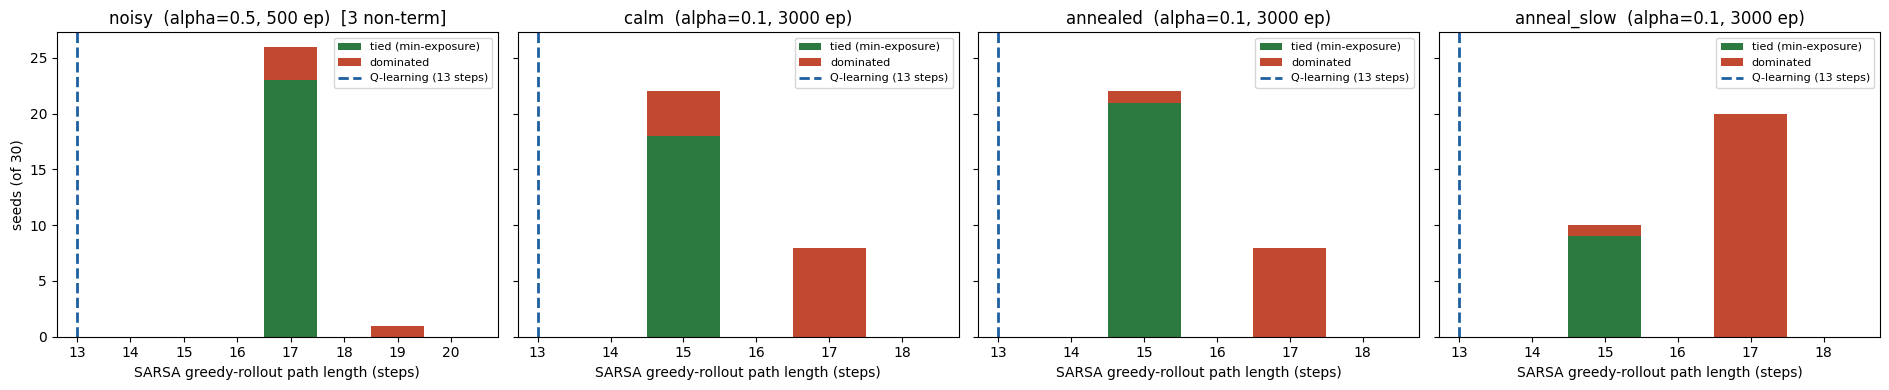

In [20]:
# Minimum safe length/exposure: SARSA's safe detour is one row up from the
# edge. Establish the per-regime minimum empirically from the seeds that
# terminate, then classify every seed against it. Lengths in STEPS.
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=True)

for ax, (name, regime) in zip(axes, REGIMES.items()):
    rolls = []
    for seed in range(N_SEEDS_10):
        total, path, term = greedy_rollout(CliffWalkingEnv(),
                                           Q_bank[('sarsa', name, seed)])
        steps = len(path) - 1
        rolls.append((steps, exposure(CliffWalkingEnv(), path, ADJ), term))
    term_lens = [L for (L, m, t) in rolls if t]
    term_exps = [m for (L, m, t) in rolls if t]
    min_len = min(term_lens) if term_lens else None
    min_exp = min(term_exps) if term_exps else None

    tied_lens, dom_lens, nonterm = [], [], 0
    for (L, m, t) in rolls:
        if not t:
            nonterm += 1
        elif L == min_len and m == min_exp:
            tied_lens.append(L)
        else:
            dom_lens.append(L)

    bins = np.arange(min(term_lens or [12]) - 1,
                     max(term_lens or [20]) + 3) - 0.5
    ax.hist([tied_lens, dom_lens], bins=bins, stacked=True,
            color=['#2c7a3f', '#c0492f'],
            label=['tied (min-exposure)', 'dominated'])
    ax.axvline(Q_REF_STEPS, color='#1e5fa0', ls='--', lw=2,
               label=f'Q-learning ({Q_REF_STEPS} steps)')
    ax.set_title(f'{name}  (alpha={regime["alpha"]}, '
                 f'{regime["n_episodes"]} ep)'
                 + (f'  [{nonterm} non-term]' if nonterm else ''))
    ax.set_xlabel('SARSA greedy-rollout path length (steps)')
    ax.legend(fontsize=8)
axes[0].set_ylabel(f'seeds (of {N_SEEDS_10})')
plt.tight_layout()
plt.show()


### SARSA greedy rollouts, six seeds (calm regime)

The histogram counts; the grid shows the actual routes. \($Q^\star$\) is unique, so Q-learning's greedy path is identical across seeds. \($Q^{\pi_\epsilon}$\) is flat across many interior routes, so SARSA's greedy policy is a sample from a *set* — genuine ties among minimum-exposure paths, plus noise-driven excursions onto dominated ones.

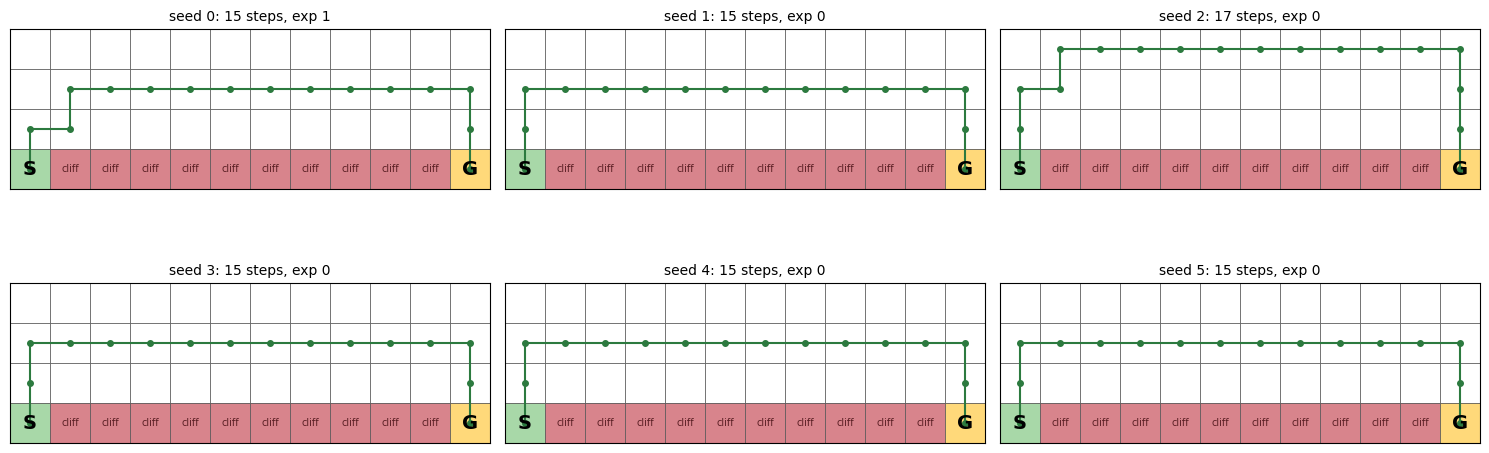

In [21]:
def path_to_coords(env, path):
    return [(s // env.W, s % env.W) for s in path]

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, seed in zip(axes.flat, range(6)):
    env = CliffWalkingEnv()
    draw_cliff(env, ax=ax, title='')
    total, path, term = greedy_rollout(CliffWalkingEnv(),
                                       Q_bank[('sarsa', 'calm', seed)])
    coords = path_to_coords(env, path)
    # Match draw_cliff's orientation: cells are painted at (H-1-r), so the
    # path must use the same vertical flip and +0.5 cell-centering. (Cell 14's
    # plot_trajectory does this correctly; the earlier version here did not.)
    xs = [c + 0.5 for (r, c) in coords]
    ys = [env.H - 1 - r + 0.5 for (r, c) in coords]
    col = '#c0492f' if not term else '#2c7a3f'
    ax.plot(xs, ys, '-o', color=col, ms=4, lw=1.5)
    m = exposure(env, path, ADJ)
    tag = 'non-term' if not term else f'{len(path) - 1} steps, exp {m}'
    ax.set_title(f'seed {seed}: {tag}', fontsize=10)
plt.tight_layout()
plt.show()


### Annealing and the GLIE visitation condition

The tempting claim is "anneal \($\epsilon \to 0$\) and SARSA converges to \($Q^\star$\), hence to the unique shortest edge path." Sutton & Barto do guarantee this — *asymptotically, and under conditions*. The conditions are the load-bearing part, and this section is a concrete study of how demanding one of them is.

**The fixed point is fine; reaching it is the problem.** For any \($\epsilon > 0$\), SARSA's fixed point \($Q^{\pi_\epsilon}$\) genuinely prefers the detour: on-policy evaluation prices in the exploratory-fall risk, so row 2 (one step from the cliff) scores below row 1, which scores below the edge. As \($\epsilon \to 0$\) that penalty vanishes and \($Q^{\pi_\epsilon} \to Q^\star$\), whose greedy policy *is* the edge. So the limit is correct. The question is whether a finite run with a decaying schedule actually gets there.

**GLIE: epsilon must vanish slowly enough.** Convergence requires \($\epsilon_k \to 0$\) *while every state-action pair is still visited infinitely often*. Once the greedy policy points away from the cliff-edge row, the agent enters that row **only** by an exploratory step — at a per-episode rate \($\sim \epsilon_k$\). By the Borel–Cantelli lemma, those states are visited infinitely often iff \($\sum_k \epsilon_k$\) diverges:

* **Geometric decay**, \($\epsilon_k \sim \text{decay}^k$\): \($\sum_k \epsilon_k < \infty$\). The cliff-edge states are visited only *finitely* often; their Q-values never converge; the GLIE condition is **violated**. The greedy policy stays on the detour no matter how long you train — not a bug, a consequence of the schedule.
* **Harmonic decay**, \($\epsilon_k = \epsilon_0/(1+ck)$\): \$(\sum_k \epsilon_k = \infty$\). The edge states keep being visited; their Q-values keep improving; the GLIE condition is **satisfied**. The price is that \($\epsilon$\) decays slowly, so convergence is slow.

**Crossover estimate.** The edge becomes greedy-preferred only once the exploratory-fall penalty no longer outweighs the \($\sim 2$\)-step saving of the edge over the detour: \($99\cdot(\epsilon/4)\cdot\Delta m < 2$\), i.e. \($\epsilon \lesssim 8/(99\,\Delta m$)\). With extra exposure \($\Delta m$\) of order a few, that is \($\epsilon \approx 0.01\text{--}0.02$\). A schedule must drive \($\epsilon$\) below this *and* keep visiting the edge to get there. The next cells show geometric decay failing the visitation test, and harmonic decay passing it.

In [22]:
from utils.toy_mdp import geometric_epsilon, harmonic_epsilon

# Two schedules, matched start (eps0 = 0.5), 60k episodes.
#   geometric: decays fast, sum eps < inf  -> GLIE visitation VIOLATED
#   harmonic:  decays slow, sum eps = inf  -> GLIE visitation SATISFIED
N_GLIE = 60_000
geo_decay = (0.01 / 0.5) ** (1.0 / 20_000)        # eps hits ~0.01 by ep 20k
geo_sched = geometric_epsilon(0.5, geo_decay, eps_min=0.0)
har_sched = harmonic_epsilon(0.5, c=7.8e-5)        # eps ~ 0.06 at ep 60k

print(f'geometric: eps@0={geo_sched(0):.3f}  eps@20k={geo_sched(20000):.4f}  '
      f'eps@60k={geo_sched(59999):.4f}')
print(f'harmonic : eps@0={har_sched(0):.3f}  eps@20k={har_sched(20000):.4f}  '
      f'eps@60k={har_sched(59999):.4f}')

def row_of(env, s):
    return s // env.W

def run_with_visits(sched, seed):
    """SARSA with a schedule; also tally visits to the cliff-edge row."""
    env = CliffWalkingEnv()
    edge_row = env.H - 2                       # row just above the cliff
    out = sarsa(env, n_episodes=N_GLIE, gamma=GAMMA, epsilon=sched,
                alpha=0.1, record_trajectories=True)
    edge_visits = sum(
        1 for traj in out['trajectories'] for (s, a) in traj
        if row_of(env, s) == edge_row
    )
    total_g, path, term = greedy_rollout(CliffWalkingEnv(), out['Q'])
    return dict(greedy_steps=len(path) - 1, term=term,
                edge_visits=edge_visits)

glie_results = {'geometric': [], 'harmonic': []}
for seed in range(3):
    glie_results['geometric'].append(run_with_visits(geo_sched, seed))
    glie_results['harmonic'].append(run_with_visits(har_sched, seed))

print()
print(f'{"schedule":<10}  {"seed":>4}  {"greedy steps":>12}  '
      f'{"edge-row visits":>16}')
print('-' * 48)
for sched_name in ('geometric', 'harmonic'):
    for seed, r in enumerate(glie_results[sched_name]):
        print(f'{sched_name:<10}  {seed:>4}  {r["greedy_steps"]:>12}  '
              f'{r["edge_visits"]:>16,}')
print()
print('Read this as the VISITATION diagnostic, not the policy outcome.')
print('At 60k episodes both schedules still give a 17-step greedy path --')
print('the difference here is purely edge-row COVERAGE: harmonic visits the')
print('cliff-edge row markedly more often than geometric. Coverage is the')
print('precondition for improvement, not improvement itself; converting it')
print('into a shorter greedy path needs a much longer horizon (see the')
print('cited long run below).')


geometric: eps@0=0.500  eps@20k=0.0100  eps@60k=0.0000
harmonic : eps@0=0.500  eps@20k=0.1953  eps@60k=0.0880



schedule    seed  greedy steps   edge-row visits
------------------------------------------------
geometric      0            17           129,902
geometric      1            17           130,001
geometric      2            17           129,841
harmonic       0            17           158,312
harmonic       1            17           157,890
harmonic       2            17           157,868

Read this as the VISITATION diagnostic, not the policy outcome.
At 60k episodes both schedules still give a 17-step greedy path --
the difference here is purely edge-row COVERAGE: harmonic visits the
cliff-edge row markedly more often than geometric. Coverage is the
precondition for improvement, not improvement itself; converting it
into a shorter greedy path needs a much longer horizon (see the
cited long run below).


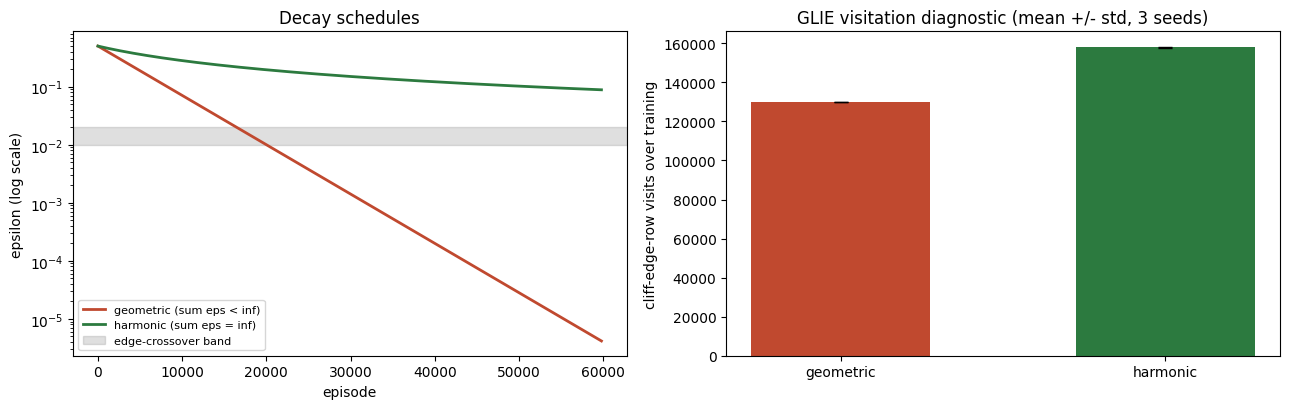

In [23]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: epsilon schedules on a log y-axis -- geometric plunges, harmonic
# decays gently. The shaded band is the crossover region eps ~ 0.01-0.02.
eps_x = np.arange(0, N_GLIE, 200)
axL.semilogy(eps_x, [geo_sched(k) for k in eps_x], color='#c0492f',
             lw=2, label='geometric (sum eps < inf)')
axL.semilogy(eps_x, [har_sched(k) for k in eps_x], color='#2c7a3f',
             lw=2, label='harmonic (sum eps = inf)')
axL.axhspan(0.01, 0.02, color='gray', alpha=0.25,
            label='edge-crossover band')
axL.set_xlabel('episode')
axL.set_ylabel('epsilon (log scale)')
axL.set_title('Decay schedules')
axL.legend(fontsize=8)

# Right: edge-row visit totals, the GLIE visitation diagnostic.
geo_v = [r['edge_visits'] for r in glie_results['geometric']]
har_v = [r['edge_visits'] for r in glie_results['harmonic']]
x = np.arange(2)
axR.bar(x[0], np.mean(geo_v), 0.55, color='#c0492f',
        yerr=np.std(geo_v), capsize=5)
axR.bar(x[1], np.mean(har_v), 0.55, color='#2c7a3f',
        yerr=np.std(har_v), capsize=5)
axR.set_xticks(x)
axR.set_xticklabels(['geometric', 'harmonic'])
axR.set_ylabel('cliff-edge-row visits over training')
axR.set_title('GLIE visitation diagnostic (mean +/- std, 3 seeds)')
plt.tight_layout()
plt.show()


### Where cliff-avoidance lives in the SARSA update

It is worth pinning down *which part* of the SARSA update encodes cliff-avoidance, because the answer is subtle: **no single term does**, and that is the essence of on-policy learning.

Compare the targets, with \($a' \sim \epsilon\text{-greedy}$\):

$$\text{SARSA: } r + \gamma\,\hat Q(s', a'), \qquad \text{Q-learning: } r + \gamma \max_{a'} \hat Q(s', a').$$

The \(-100\) of a fall enters through the ordinary reward term \($r$\) — nothing special; it is just the reward of the transition that happened. The cliff-*avoidance*, though, is not in \($r$\) and not in any explicit penalty. It lives in the **bootstrap term \($\gamma$\,$\hat Q(s', a')$\)**, and specifically in the fact that \($a'$\) is sampled from the \($\epsilon$\)-greedy *behaviour* policy — exploratory branch included.

The mechanism: when an exploratory \($a'$\) steps into the cliff, that \(-100\) depresses \($\hat Q$\) at the edge-adjacent state. SARSA's target for the *preceding* state-action pair is \($r + \gamma\,\hat Q(s', a')$\), and \($\hat Q(s', a')$\) — averaged over what the \($\epsilon$\)-greedy policy actually does, which is fall \($\epsilon/4$\) of the time — is therefore depressed. The fall risk propagates backward not as a penalty but as a **lowered bootstrap value, carried by the on-policy sampling of \($a'$\)**.

Q-learning's \($\max$\) *deletes* the exploratory branch: it asks "what if I continued greedily," so its bootstrap never sees the fall. Same \($r$\), same \($\gamma$\); the entire difference is expectation-over-behaviour versus max.

Strictly, SARSA does not "minimise falling" at all. It solves the Bellman equation \($Q^{\pi_\epsilon} = r + \gamma\,\mathbb{E}_{a'\sim\pi_\epsilon}[Q^{\pi_\epsilon}(s',a')]$\). The expected fall cost is baked into the *fixed point*, because the expectation is over a policy that falls. "SARSA avoids the cliff" is shorthand for "SARSA's greedy policy is the argmax of \($Q^{\pi_\epsilon}$\), and \($Q^{\pi_\epsilon}$\) scores edge states low because the policy it evaluates falls off the edge."

### Cited long run: harmonic decay over 200k episodes

The 60k-episode cell above shows the *visitation* difference but not yet a *policy* difference — both schedules still give a 17-step greedy path at that horizon. Converting improved coverage into a shorter greedy path needs a much longer run. The following was produced separately (harmonic decay, \($\epsilon_0 = 0.5$\), \($c = 7.8\times10^{-5}$\), 200k episodes, \($\alpha = 0.1$\)); it is cited here rather than run inline because a 200k-episode cell is too slow for routine notebook execution.

| checkpoint | epsilon | greedy steps (seed 0) | (seed 1) | (seed 2) |
|-----------:|--------:|----------------------:|---------:|---------:|
|     10,000 |   0.390 |                    17 |       17 |       17 |
|     30,000 |   0.211 |                    17 |       17 |       17 |
|     60,000 |   0.120 |                    17 |       17 |       17 |
|    100,000 |   0.063 |                    17 |       17 |       17 |
|    150,000 |   0.044 |                    15 |       15 |       17 |
|    200,000 |   0.030 |                    15 |       15 |       17 |

Edge-row visits over the 200k run: ~455k (harmonic) versus ~130k for a geometric schedule — a 3.5x coverage gain.

Two things to read from this. First, the descent is **real and monotone**: the greedy path shortens \(17 	o 15\) as \(\epsilon\) falls, which is SARSA's greedy policy provably moving toward the edge — the asymptotic convergence is *in progress*. Second, it is **slow and not yet complete**: at \($\epsilon \approx 0.03$\) the run sits at 15 steps, and the crossover estimate \(\epsilon \lesssim 0.02\) says the final \(15 	o 14 	o 13\) flip onto the true edge path requires driving \($\epsilon$\) lower still — several times more episodes on a harmonic schedule. Seed 2 lagging at 17 is the same coverage effect one seed deeper: GLIE guarantees infinitely-often visitation in the limit, not uniform progress at finite time.

The 13-step edge path is therefore a *predicted asymptotic limit*, consistent with Sutton & Barto, evidenced here by the monotone \(17	o15\) trend plus the crossover arithmetic — not by a run we let finish.